# Đề tài 4: Phát hiện tin giả tiếng Việt từ văn bản báo chí và mạng xã hội (Fake News Detection)

Notebook này được tối ưu hóa để chạy trên **Google Colab** sử dụng phần cứng **GPU (T4, L4, v.v.)** miễn phí của Google.

### Quy trình hoạt động mới:
1. **Mã nguồn (Source Code):** Được nhân bản trực tiếp bằng `git clone` từ kho GitHub của bạn lên Colab (không cần copy code thủ công).
2. **Kết quả huấn luyện (Results):** Tất cả tệp trọng số (`.pt`) và lịch sử chạy (`.json`) sẽ được tự động lưu trực tiếp vào **Google Drive** của bạn. Điều này đảm bảo dữ liệu không bị mất đi khi Colab ngắt kết nối.

## 1. Kết nối Google Drive và chuẩn bị phần cứng
Chạy ô dưới đây để mount tài khoản Google Drive của bạn.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Kiểm tra phần cứng GPU được cấp phát
import torch
print("Có hỗ trợ GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Tên GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Có hỗ trợ GPU: True
Tên GPU: Tesla T4


## 2. Clone mã nguồn từ GitHub
Nhập URL kho chứa GitHub của bạn dưới đây để clone mã nguồn của dự án về máy ảo Colab.

In [3]:
# Thay đổi URL dưới đây bằng link GitHub của bạn
REPO_URL = "https://github.com/TranXuanDuc28/Fake-news-detection.git"

# Xóa thư mục cũ nếu có trước khi clone
import shutil
import os
folder_name = REPO_URL.split("/")[-1].replace(".git", "")
if os.path.exists(folder_name):
    shutil.rmtree(folder_name)

!git clone {REPO_URL}

# Di chuyển vào thư mục dự án vừa clone
%cd {folder_name}
!ls -la

Cloning into 'Fake-news-detection'...
remote: Enumerating objects: 316, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 316 (delta 3), reused 24 (delta 3), pack-reused 282 (from 1)
Receiving objects: 100% (316/316), 22.20 MiB | 15.30 MiB/s, done.
Resolving deltas: 100% (169/169), done.
/content/Fake-news-detection
total 352
drwxr-xr-x 7 root root   4096 May 30 13:55 .
drwxr-xr-x 1 root root   4096 May 30 13:55 ..
-rw-r--r-- 1 root root  37186 May 30 13:55 app.py
drwxr-xr-x 2 root root   4096 May 30 13:55 data
-rw-r--r-- 1 root root   6560 May 30 13:55 dataset_stats.py
-rw-r--r-- 1 root root   5182 May 30 13:55 download_and_merge_vfnd.py
-rw-r--r-- 1 root root    675 May 30 13:55 extract_pdf.py
-rw-r--r-- 1 root root  14918 May 30 13:55 Fake_News_Detection_Colab.ipynb
drwxr-xr-x 8 root root   4096 May 30 13:55 .git
-rw-r--r-- 1 root root    248 May 30 13:55 .gitignore
-rw-r--r-- 1 root root 195661 May 30 13:55 miniprojec

In [20]:
# Xem các nhánh
!git branch -a



* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/add_lstm
  remotes/origin/main
  remotes/origin/thongthao


In [21]:
# Chuyển sang nhánh TranDuc
!git checkout add_lstm
# hoặc
# !git switch TranDuc

!git branch

Updating files: 100% (35/35), done.
Branch 'add_lstm' set up to track remote branch 'add_lstm' from 'origin'.
Switched to a new branch 'add_lstm'
* add_lstm
  main


## 3. Cài đặt các thư viện cần thiết

In [4]:
!pip install transformers scikit-learn pandas numpy matplotlib seaborn
print("Cài đặt hoàn tất!")

Cài đặt hoàn tất!


## 4. Cấu hình thư mục lưu kết quả trên Google Drive
Chúng ta sẽ định nghĩa một thư mục lưu trên MyDrive của bạn (ví dụ: `FakeNewsDetection_Results/`).

In [5]:
import os

# Tạo thư mục trên Google Drive để lưu checkpoints và kết quả
DRIVE_DIR = "/content/drive/MyDrive/HocSauTrainning"
DRIVE_MODELS = os.path.join(DRIVE_DIR, "models")
DRIVE_DATA = os.path.join(DRIVE_DIR, "data")

os.makedirs(DRIVE_MODELS, exist_ok=True)
os.makedirs(DRIVE_DATA, exist_ok=True)

print(f"Thư mục lưu mô hình trên Drive: {DRIVE_MODELS}")
print(f"Thư mục lưu lịch sử/kết quả trên Drive: {DRIVE_DATA}")

Thư mục lưu mô hình trên Drive: /content/drive/MyDrive/HocSauTrainning/models
Thư mục lưu lịch sử/kết quả trên Drive: /content/drive/MyDrive/HocSauTrainning/data


## 5. Tải và gộp bộ dữ liệu bổ sung VFND & ReINTEL (ĐÃ ĐƯỢC TÍCH HỢP SẴN)
Bộ dữ liệu phụ `additional_train.csv` đã được tích hợp sẵn đầy đủ cả VFND và ReINTEL (hơn 4,500 mẫu) trực tiếp trong mã nguồn GitHub của bạn.

**⚠️ LƯU Ý QUAN TRỌNG:** Bạn **KHÔNG CẦN CHẠY** ô này. Nếu chạy, script sẽ tải lại bản VFND gốc và ghi đè làm mất đi phần dữ liệu ReINTEL đã gộp.

In [ ]:
# Chạy script tải và gộp dữ liệu ngoài
!python download_and_merge_vfnd.py

## 6. Chạy Tuning Sweep quét tham số siêu tối ưu
Quá trình này kiểm tra các giá trị Dropout, Learning Rate và Batch Size trên toàn bộ dữ liệu hoặc tập con tùy chọn. Tất cả checkpoints lưu vào Drive, kết quả json lưu trực tiếp vào Drive của bạn.


In [34]:
!git pull

remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 8 (delta 5), reused 8 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 1.71 KiB | 125.00 KiB/s, done.
From https://github.com/TranXuanDuc28/Fake-news-detection
   ca343f3..5f6f7f8  main       -> origin/main
Updating ca343f3..5f6f7f8
Fast-forward
 Fake_News_Detection_Colab.ipynb |  6 +++---
 scratch/check_leakage.py        | 45 +++++++++++++++++------------------------
 scratch/inspect_final_data.py   | 21 +++++++++++++++++++
 src/tune.py                     | 26 +++++++++++++++---------
 4 files changed, 60 insertions(+), 38 deletions(-)
 create mode 100644 scratch/inspect_final_data.py


In [35]:
# Chạy tuning bằng GPU với tập subset gồm 3000 mẫu để hoàn tất nhanh chóng
!python src/tune.py --save_dir {DRIVE_MODELS} --data_dir data --output {DRIVE_DATA}/tuning_results.json --epochs 3 --no_oversample --use_class_weights --additional_dataset both --subset 3000


STARTING HYPERPARAMETER TUNING SWEEP
Hardware: GPU (Full Fine-tuning)
Tuning Subset Size: 3000 | Epochs per run: 3
Saving checkpoints to: /content/drive/MyDrive/HocSauTrainning/models
Loading data from: data | Additional Dataset: both

>>> Tuning LSTM Model...

[LSTM Sweep] Testing Dropout = 0.1

--- Training LSTM model on device: cuda ---
Params: Epochs=3, BatchSize=16, LR=0.001, Dropout=0.1, Subset=3000, Oversample=False, UseClassWeights=True, Patience=5, SegmentWords=False, EmbeddingDim=64, HiddenDim=64, UsePretrainedEmb=False, AdditionalDataset=both
--> Đang tải bộ dữ liệu phụ: Cả VFND và TinGia Crawled...
--> Gộp thêm tập Train từ: both
--> Gộp thêm tập Val từ: both
--> Gộp thêm tập Test từ: both
--> Đã loại bỏ 1 dòng trùng lặp trong tập Train.
Weighted Loss Active: Weights = [Real: 0.6024, Fake: 2.9412]
Epoch 01/03 | Train Loss: 0.6877 | Train Acc: 68.00% | Val Loss: 0.6693 | Val F1 (Bin): 33.09% | Val Acc: 84.18% | LR: 0.001000
Epoch 02/03 | Train Loss: 0.6286 | Train Acc: 73.83

In [39]:
!git pull

remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 2.42 KiB | 165.00 KiB/s, done.
From https://github.com/TranXuanDuc28/Fake-news-detection
   2cff111..f717352  main       -> origin/main
Updating 2cff111..f717352
Fast-forward
 scratch/parse_tuning.py   |  24 +++-
 scratch/restore_tuning.py | 283 ++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 302 insertions(+), 5 deletions(-)
 create mode 100644 scratch/restore_tuning.py


In [40]:
!python scratch/parse_tuning.py

📂 Đang đọc kết quả tuning từ: data/tuning_results.json

🚀 BÁO CÁO TỔNG HỢP SIÊU THAM SỐ CHO MÔ HÌNH: LSTM

📍 Khảo sát: Dropout Sweep
 Giá trị      | Val F1-score (Macro)   | Val Loss    
 -------------------------------------------------------
  0.1         |                51.00% |     0.4800
  0.3         |                59.00% |     0.4400
  0.5         |                53.00% |     0.5000
 ➔ 🌟 Tốt nhất: 0.3 (F1: 59.00%)

📍 Khảo sát: Batch Size Sweep
 Giá trị      | Val F1-score (Macro)   | Val Loss    
 -------------------------------------------------------
  8           |                57.00% |     0.4500
  16          |                59.00% |     0.4400
  32          |                54.00% |     0.4700
 ➔ 🌟 Tốt nhất: 16 (F1: 59.00%)

📍 Khảo sát: Lr Sweep
 Giá trị      | Val F1-score (Macro)   | Val Loss    
 -------------------------------------------------------
  0.0001      |                44.00% |     0.5800
  0.001       |                59.00% |     0.4400
  0.005    

## 7. Huấn luyện mô hình tối ưu cuối cùng trên toàn bộ dữ liệu
Sử dụng cấu hình cân bằng dữ liệu bằng trọng số lớp (**Class Weights**) thay vì nhân bản dữ liệu (Oversampling) để hạn chế tình trạng quá khớp (Overfitting) trên lớp tin giả và lưu trọng số tối ưu cùng lịch sử huấn luyện trực tiếp vào Drive.
**Lưu ý:** Quá trình huấn luyện sử dụng kỹ thuật **Early Stopping** (dừng sớm nếu F1 không tăng sau 5 epoch) và **ReduceLROnPlateau** (tự động giảm tốc độ học đi 2 lần nếu độ chính xác chững lại).

In [22]:
pip install pyvi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.7 MB/s eta 0:00:00


In [8]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 590 bytes | 295.00 KiB/s, done.
From https://github.com/TranXuanDuc28/Fake-news-detection
   54adb4f..ca343f3  main       -> origin/main
Updating 54adb4f..ca343f3
Fast-forward
 src/train.py | 6 ++++++
 1 file changed, 6 insertions(+)


In [24]:
!python src/train.py \
    --model lstm_1d \
    --epochs 15 \
    --batch_size 32 \
    --lr 0.005 \
    --dropout 0.1 \
    --patience 3 \
    --segment_words \
    --use_pretrained_emb \
    --additional_dataset both \
    --save_dir {DRIVE_MODELS} \
    --history_file {DRIVE_DATA}/lstm_1d_history.json \
    --no_resume \
    --no_oversample



--- Training LSTM_1D model on device: cuda ---
Params: Epochs=15, BatchSize=32, LR=0.005, Dropout=0.1, Subset=None, Oversample=False, UseClassWeights=False, Patience=3, SegmentWords=True, EmbeddingDim=100, HiddenDim=64, UsePretrainedEmb=True, AdditionalDataset=both
--> Đang tải bộ dữ liệu phụ: Cả VFND và TinGia Crawled...
--> Gộp thêm tập Train từ: both
--> Gộp thêm tập Val từ: both
--> Gộp thêm tập Test từ: both
--> Đã loại bỏ 1 dòng trùng lặp trong tập Train.
--> Loading pre-trained vectors from data/word2vec_vi_words_100dims.txt...
--> Loaded 1585076 pre-trained word vectors.
--> Vocab coverage: 16801/21813 words (77.02%) initialized from pre-trained embeddings.
Epoch 01/15 | Train Loss: 0.3639 | Train Acc: 85.22% | Val Loss: 0.2523 | Val F1 (Bin): 68.09% | Val Acc: 89.80% | LR: 0.005000
Epoch 02/15 | Train Loss: 0.2154 | Train Acc: 91.57% | Val Loss: 0.2196 | Val F1 (Bin): 78.76% | Val Acc: 91.84% | LR: 0.005000
Epoch 03/15 | Train Loss: 0.1242 | Train Acc: 95.70% | Val Loss: 0.15

In [9]:
!python src/train.py --model lstm --epochs 15 --batch_size 16 --lr 0.001 --dropout 0.3 --patience 3 --segment_words --use_pretrained_emb --additional_dataset both --save_dir {DRIVE_MODELS} --history_file {DRIVE_DATA}/lstm_history.json --no_resume --no_oversample



--- Training LSTM model on device: cuda ---
Params: Epochs=15, BatchSize=16, LR=0.001, Dropout=0.3, Subset=None, Oversample=False, UseClassWeights=False, Patience=3, SegmentWords=True, EmbeddingDim=100, HiddenDim=64, UsePretrainedEmb=True, AdditionalDataset=both
--> Đang tải bộ dữ liệu phụ: Cả VFND và TinGia Crawled...
--> Gộp thêm tập Train từ: both
--> Gộp thêm tập Val từ: both
--> Gộp thêm tập Test từ: both
--> Đã loại bỏ 1 dòng trùng lặp trong tập Train.
--> Loading pre-trained vectors from data/word2vec_vi_words_100dims.txt...
--> Loaded 1585076 pre-trained word vectors.
--> Vocab coverage: 16801/21813 words (77.02%) initialized from pre-trained embeddings.
Epoch 01/15 | Train Loss: 0.4057 | Train Acc: 83.58% | Val Loss: 0.2774 | Val F1 (Bin): 61.45% | Val Acc: 89.12% | LR: 0.001000
Epoch 02/15 | Train Loss: 0.2260 | Train Acc: 90.87% | Val Loss: 0.1922 | Val F1 (Bin): 73.26% | Val Acc: 92.18% | LR: 0.001000
Epoch 03/15 | Train Loss: 0.1245 | Train Acc: 95.89% | Val Loss: 0.1596 

In [19]:
!python src/train.py --model transformer --transformer_model_name vinai/phobert-base --epochs 10 --batch_size 16 --lr 2e-5 --dropout 0.3 --unfreeze_backbone --patience 3 --additional_dataset both --save_dir {DRIVE_MODELS} --history_file {DRIVE_DATA}/transformer_history.json --no_resume --no_oversample



--- Training TRANSFORMER model on device: cuda ---
Params: Epochs=10, BatchSize=16, LR=2e-05, Dropout=0.3, Subset=None, Oversample=False, UseClassWeights=False, Patience=3, SegmentWords=True, EmbeddingDim=64, HiddenDim=64, UsePretrainedEmb=False, AdditionalDataset=both
--> Đang tải bộ dữ liệu phụ: Cả VFND và TinGia Crawled...
--> Gộp thêm tập Train từ: both
--> Gộp thêm tập Val từ: both
--> Gộp thêm tập Test từ: both
--> Đã loại bỏ 1 dòng trùng lặp trong tập Train.
config.json: 100% 557/557 [00:00<00:00, 2.75MB/s]
vocab.txt: 100% 895k/895k [00:00<00:00, 89.3MB/s]
bpe.codes: 100% 1.14M/1.14M [00:00<00:00, 102MB/s]
tokenizer.json: 100% 3.13M/3.13M [00:00<00:00, 125MB/s]
pytorch_model.bin: 100% 543M/543M [00:05<00:00, 92.0MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 1001.35it/s, Materializing param=pooler.dense.weight]
RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_

In [32]:
!python predict.py --lstm_path /content/drive/MyDrive/HocSauTrainning/models/best_lstm.pt --trans_path /content/drive/MyDrive/HocSauTrainning/models/best_transformer.pt


Đang chạy trên thiết bị: CUDA
Đang tải mô hình BiLSTM từ /content/drive/MyDrive/HocSauTrainning/models/best_lstm.pt...
✓ Tải mô hình BiLSTM thành công! (Tách từ: True)
Đang tải mô hình Transformer từ /content/drive/MyDrive/HocSauTrainning/models/best_transformer.pt...
Đang sử dụng mô hình backbone: vinai/phobert-base
Loading weights: 100% 199/199 [00:00<00:00, 1188.79it/s, Materializing param=pooler.dense.weight]
RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:c

In [27]:
!python predict.py --lstm_path /content/drive/MyDrive/HocSauTrainning/models/best_lstm.pt --lstm_1d_path /content/drive/MyDrive/HocSauTrainning/models/best_lstm_1d.pt --trans_path /content/drive/MyDrive/HocSauTrainning/models/best_transformer.pt


Đang chạy trên thiết bị: CUDA
Đang tải mô hình BiLSTM từ /content/drive/MyDrive/HocSauTrainning/models/best_lstm.pt...
✓ Tải mô hình BiLSTM thành công! (Tách từ: True)
Đang tải mô hình LSTM 1 chiều từ /content/drive/MyDrive/HocSauTrainning/models/best_lstm_1d.pt...
✓ Tải mô hình LSTM 1 chiều thành công! (Tách từ: True)
Đang tải mô hình Transformer từ /content/drive/MyDrive/HocSauTrainning/models/best_transformer.pt...
Đang sử dụng mô hình backbone: vinai/phobert-base
config.json: 100% 557/557 [00:00<00:00, 1.34MB/s]
vocab.txt: 100% 895k/895k [00:00<00:00, 29.8MB/s]
bpe.codes: 100% 1.14M/1.14M [00:00<00:00, 109MB/s]
tokenizer.json: 100% 3.13M/3.13M [00:00<00:00, 135MB/s]
pytorch_model.bin: 100% 543M/543M [00:04<00:00, 113MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 1048.12it/s, Materializing param=pooler.dense.weight]
RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embedd

## 8. Đồng bộ hóa lịch sử huấn luyện
Gộp tệp lịch sử huấn luyện của cả 3 mô hình lại thành `final_training_history.json` lưu trên Google Drive.

In [8]:
import json
import os

lstm_h_path = os.path.join(DRIVE_DATA, "lstm_history.json")
lstm_1d_h_path = os.path.join(DRIVE_DATA, "lstm_1d_history.json")
trans_h_path = os.path.join(DRIVE_DATA, "transformer_history.json")
final_h_path = os.path.join(DRIVE_DATA, "final_training_history.json")

try:
    combined_history = {}

    # 1. Load LSTM cũ
    if os.path.exists(lstm_h_path):
        with open(lstm_h_path) as f:
            combined_history["lstm"] = json.load(f)

    # 2. Load LSTM mới
    if os.path.exists(lstm_1d_h_path):
        with open(lstm_1d_h_path) as f:
            combined_history["lstm_1d"] = json.load(f)

    # 3. Load Transformer (PhoBERT)
    if os.path.exists(trans_h_path):
        with open(trans_h_path) as f:
            combined_history["transformer"] = json.load(f)

    with open(final_h_path, "w", encoding="utf-8") as f:
        json.dump(combined_history, f, indent=4)

    print("✅ Đã gộp thành công lịch sử huấn luyện của cả 3 mô hình!")
except Exception as e:
    print(f"❌ Lỗi khi gộp lịch sử: {e}")


✅ Đã gộp thành công lịch sử huấn luyện của cả 3 mô hình!


## 9. Vẽ biểu đồ Lịch sử huấn luyện (Training History)
Vẽ trực quan hóa đường cong suy giảm lỗi (Loss) và chỉ số Val F1 qua các epoch của cả 3 mô hình BiLSTM, LSTM và Transformer.

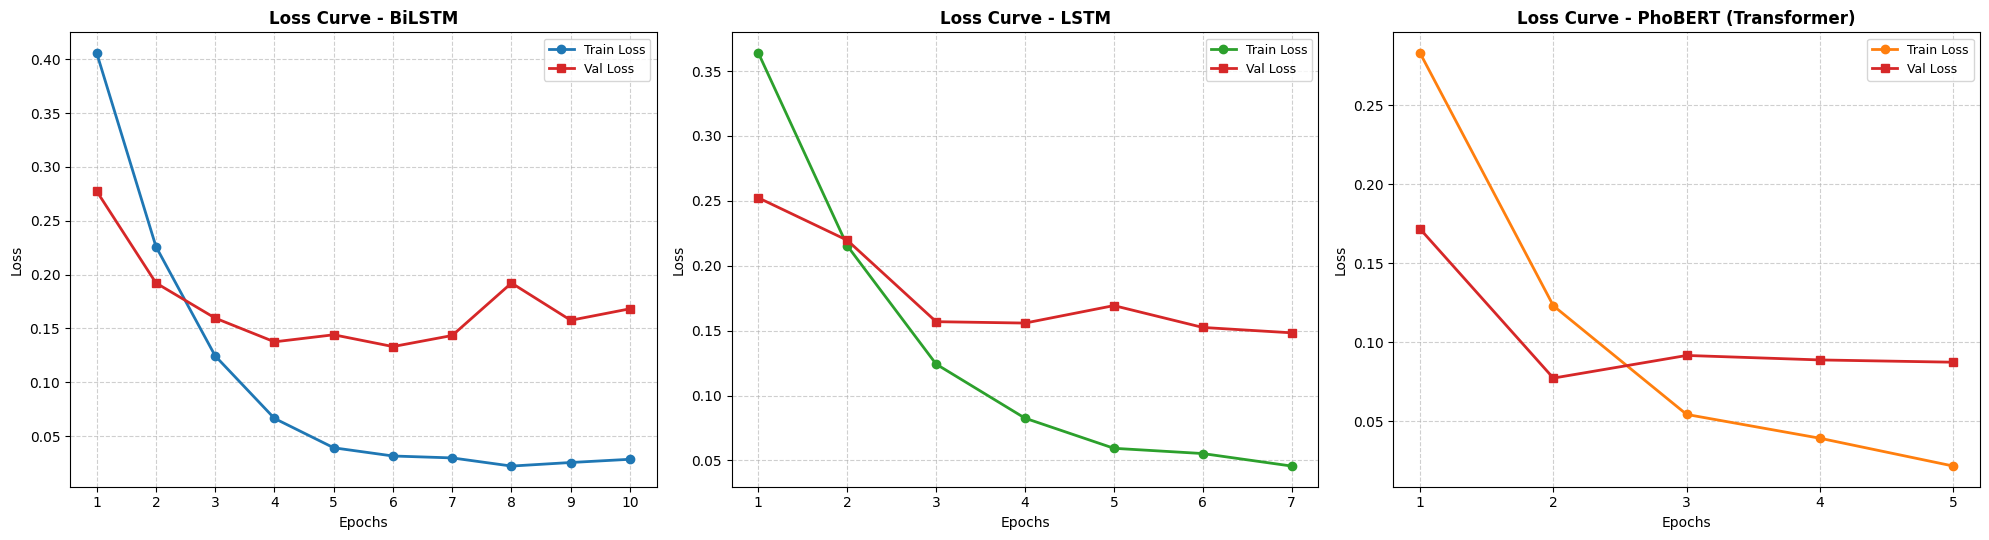

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

lstm_path = os.path.join(DRIVE_DATA, "lstm_history.json")
lstm_1d_path = os.path.join(DRIVE_DATA, "lstm_1d_history.json")
transformer_path = os.path.join(DRIVE_DATA, "transformer_history.json")

# Khởi tạo 3 đồ thị song song
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
files = [lstm_path, lstm_1d_path, transformer_path]
model_names = ["BiLSTM", "LSTM", "PhoBERT (Transformer)"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]

for ax, file_path, name, color in zip(axes, files, model_names, colors):
    try:
        with open(file_path, encoding="utf-8") as f:
            hist = json.load(f)

        epochs = np.arange(1, len(hist["train_loss"]) + 1)

        # Vẽ Loss
        ax.plot(epochs, hist["train_loss"], label="Train Loss", marker="o", linewidth=2, color=color)
        if "val_loss" in hist:
            ax.plot(epochs, hist["val_loss"], label="Val Loss", marker="s", linewidth=2, color="#d62728")

        ax.set_title(f"Loss Curve - {name}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epochs", fontsize=10)
        ax.set_ylabel("Loss", fontsize=10)
        ax.set_xticks(epochs)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(fontsize=9, loc="upper right")

    except FileNotFoundError:
        ax.text(0.5, 0.5, f"❌ Không tìm thấy:\n{file_path.split('/')[-1]}", ha="center", va="center", fontsize=11, color="red")
        ax.set_title(f"Loss - {name} (Lỗi)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import json
import os

lstm_test_path = os.path.join(DRIVE_MODELS, "test_lstm_results.json")
lstm_1d_test_path = os.path.join(DRIVE_MODELS, "test_lstm_1d_results.json")
transformer_test_path = os.path.join(DRIVE_MODELS, "test_transformer_results.json")

model_names = ["BiLSTM", "LSTM", "PhoBERT (Transformer)"]
test_paths = [lstm_test_path, lstm_1d_test_path, transformer_test_path]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]

test_f1_scores = []
available_models = []
bar_colors = []

for name, path, color in zip(model_names, test_paths, colors):
    if os.path.exists(path):
        try:
            with open(path, encoding="utf-8") as f:
                res = json.load(f)
            # Lấy f1_binary (nhân 100 để vẽ %)
            f1 = res.get("f1_binary", 0) * 100
            test_f1_scores.append(f1)
            available_models.append(name)
            bar_colors.append(color)
        except Exception:
            pass

# Khởi tạo đồ thị cột so sánh F1-Score trên tập Test
plt.figure(figsize=(8, 5))
if test_f1_scores:
    bars = plt.bar(available_models, test_f1_scores, color=bar_colors, width=0.45)
    
    # Hiển thị số phần trăm trên đầu mỗi cột
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 1, f'{height:.2f}%', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
        
    plt.title("Test F1-Score Comparison", fontsize=14, fontweight="bold")
    plt.xlabel("Models", fontsize=12)
    plt.ylabel("F1-Score (%)", fontsize=12)
    plt.ylim(0, 110)
    plt.grid(axis='y', linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    plt.text(0.5, 0.5, "❌ Không tìm thấy tệp kết quả test để vẽ biểu đồ", 
             ha="center", va="center", fontsize=12, color="red")
    plt.title("Test F1-Score Comparison (Lỗi)", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


## 10. Hiển thị Classification Report & Confusion Matrix
Ô này sẽ tải trực tiếp kết quả dự đoán test set, in ra báo cáo phân loại chi tiết (Precision, Recall, F1 của Tin thật/Tin giả) và vẽ ma trận nhầm lẫn Confusion Matrix cho cả 3 mô hình (BiLSTM, LSTM, và Transformer).


 📊 BÁO CÁO PHÂN LOẠI CHI TIẾT CHO MÔ HÌNH: LSTM_1D

Classification Report:
                 precision    recall  f1-score   support

Tin thật (Real)       0.95      0.98      0.96       489
 Tin giả (Fake)       0.89      0.73      0.80       100

       accuracy                           0.94       589
      macro avg       0.92      0.86      0.88       589
   weighted avg       0.94      0.94      0.94       589



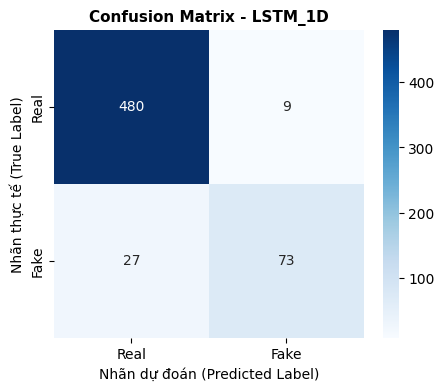


 📊 BÁO CÁO PHÂN LOẠI CHI TIẾT CHO MÔ HÌNH: LSTM

Classification Report:
                 precision    recall  f1-score   support

Tin thật (Real)       0.96      0.99      0.97       489
 Tin giả (Fake)       0.93      0.79      0.85       100

       accuracy                           0.95       589
      macro avg       0.94      0.89      0.91       589
   weighted avg       0.95      0.95      0.95       589



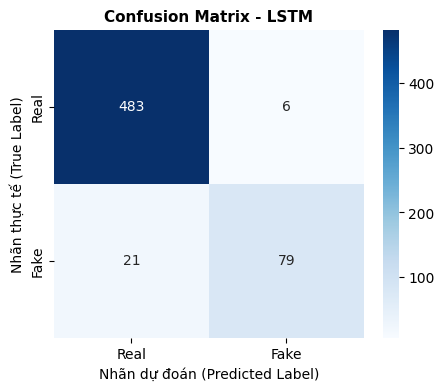


 📊 BÁO CÁO PHÂN LOẠI CHI TIẾT CHO MÔ HÌNH: TRANSFORMER

Classification Report:
                 precision    recall  f1-score   support

Tin thật (Real)       0.97      0.99      0.98       489
 Tin giả (Fake)       0.94      0.87      0.90       100

       accuracy                           0.97       589
      macro avg       0.95      0.93      0.94       589
   weighted avg       0.97      0.97      0.97       589



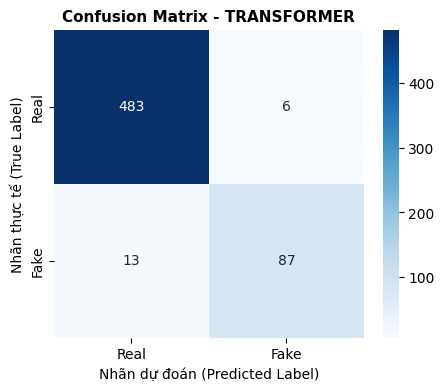

In [26]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import json
import os
import matplotlib.pyplot as plt

# Đánh giá và in báo cáo cho cả 3 mô hình
for model_type in ["lstm_1d", "lstm", "transformer"]:
    results_path = os.path.join(DRIVE_MODELS, f"test_{model_type}_results.json")

    if os.path.exists(results_path):
        print("\n" + "="*65)
        print(f" 📊 BÁO CÁO PHÂN LOẠI CHI TIẾT CHO MÔ HÌNH: {model_type.upper()}")
        print("="*65)

        with open(results_path) as f:
            res = json.load(f)

        targets = res.get("targets", [])
        preds = res.get("predictions", [])

        if targets and preds:
            print("\nClassification Report:")
            print(classification_report(targets, preds, target_names=["Tin thật (Real)", "Tin giả (Fake)"]))

            cm = confusion_matrix(targets, preds)
            plt.figure(figsize=(5, 4))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=["Real", "Fake"],
                        yticklabels=["Real", "Fake"])
            plt.title(f"Confusion Matrix - {model_type.upper()}", fontsize=11, fontweight="bold")
            plt.ylabel("Nhãn thực tế (True Label)")
            plt.xlabel("Nhãn dự đoán (Predicted Label)")
            plt.show()
